# 05 - Evaluation: Stage 1 vs Stage 2 (RL)
Compare the pre-trained model against the RL fine-tuned model on the test set.

## Setup Instructions
1. Both Stage 1 and Stage 2 training must be complete
2. Checkpoints must exist at `MyDrive/CiteMind/checkpoints/`
3. Set runtime to **A100 GPU**
4. Run all cells in order

In [1]:
# ── Step 1: Mount Google Drive ──────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

DRIVE_DIR   = '/content/drive/MyDrive/CiteMind'
PRETRAIN_CKPT = f'{DRIVE_DIR}/checkpoints/pretrain/checkpoint_best.pt'
RL_CKPT       = f'{DRIVE_DIR}/checkpoints/rl/checkpoint_best_rl.pt'
EVAL_OUTPUT   = f'{DRIVE_DIR}/evaluation_results.json'

import os
assert os.path.exists(PRETRAIN_CKPT), f'Stage 1 checkpoint not found: {PRETRAIN_CKPT}'
assert os.path.exists(RL_CKPT), f'Stage 2 checkpoint not found: {RL_CKPT}'

# Show which RL checkpoint is loaded
import torch
rl_ckpt_info = torch.load(RL_CKPT, map_location='cpu', weights_only=False)
print('Drive mounted.')
print(f'Stage 1 checkpoint : OK')
print(f'Stage 2 checkpoint : OK  (step={rl_ckpt_info["step"]}, best_reward={rl_ckpt_info["best_reward"]:.4f})')
del rl_ckpt_info

Mounted at /content/drive
Drive mounted.
Stage 1 checkpoint : OK
Stage 2 checkpoint : OK  (step=450, best_reward=0.1594)


In [2]:
# ── Step 2: Clone / pull repo ────────────────────────────────────────────
import os
if not os.path.exists('/content/repo'):
    !git clone https://github.com/mohamedzait20003/ECE595NLP-Project /content/repo
else:
    !git -C /content/repo pull origin main
%cd /content/repo
print('Repo ready.')

Cloning into '/content/repo'...
remote: Enumerating objects: 454, done.
remote: Counting objects: 100% (157/157), done.
remote: Compressing objects: 100% (109/109), done.
remote: Total 454 (delta 94), reused 92 (delta 48), pack-reused 297 (from 1)
Receiving objects: 100% (454/454), 7.83 MiB | 21.45 MiB/s, done.
Resolving deltas: 100% (286/286), done.
/content/repo
Repo ready.


In [3]:
# ── Step 3: Install dependencies ─────────────────────────────────────────
!apt-get install -q libsndfile1
!pip install -q -r requirements.txt
!pip install -q torch --index-url https://download.pytorch.org/whl/cu124
!pip install -q sentence-transformers
print('Dependencies installed.')

Reading package lists...
Building dependency tree...
Reading state information...
libsndfile1 is already the newest version (1.0.31-2ubuntu0.2).
0 upgraded, 0 newly installed, 0 to remove and 42 not upgraded.
Dependencies installed.


In [4]:
# ── Step 4: Extract data ─────────────────────────────────────────────────
import os, json, re
from pathlib import Path

DATA_ZIP = f'{DRIVE_DIR}/data.zip'

if not os.path.exists(DATA_ZIP):
    raise FileNotFoundError(
        f'Data zip not found at {DATA_ZIP}\n'
        'Please upload data.zip to MyDrive/CiteMind/ in Google Drive.'
    )

print(f'Found: {DATA_ZIP}')
!unzip -q -o "{DATA_ZIP}" -d /content/repo/src/data
print('Zip extracted.')

# Patch Windows absolute paths in manifest JSON files
AUDIO_BASE = '/content/repo/src/data/audio'
target = Path('/content/repo/src/data')

for manifest_name in ['train_manifest.json', 'val_manifest.json', 'test_manifest.json']:
    manifest_path = target / 'audio' / manifest_name
    if not manifest_path.exists():
        continue
    with open(manifest_path, 'r', encoding='utf-8') as f:
        entries = json.load(f)
    patched = 0
    for entry in entries:
        ap = entry.get('audio_path', '')
        if not ap.startswith('/content'):
            parts = re.split(r'[/\\\\]', ap)
            fname  = parts[-1]
            subdir = parts[-2] if len(parts) >= 2 else manifest_name.split('_')[0]
            entry['audio_path'] = f'{AUDIO_BASE}/{subdir}/{fname}'
            patched += 1
    with open(manifest_path, 'w', encoding='utf-8') as f:
        json.dump(entries, f)
    print(f'  Patched {patched} paths in {manifest_name}')

TEST_MANIFEST = '/content/repo/src/data/audio/test_manifest.json'
assert os.path.exists(TEST_MANIFEST), f'Test manifest not found: {TEST_MANIFEST}'
with open(TEST_MANIFEST, 'r') as f:
    n_test = len(json.load(f))
print(f'\nTest samples: {n_test}')

Found: /content/drive/MyDrive/CiteMind/data.zip
Zip extracted.
  Patched 63971 paths in train_manifest.json
  Patched 7996 paths in val_manifest.json
  Patched 7997 paths in test_manifest.json

Test samples: 7997


In [5]:
# ── Step 5: Verify GPU ───────────────────────────────────────────────────
import sys, torch
sys.path.insert(0, '/content/repo')

assert torch.cuda.is_available(), 'No GPU found! Set runtime to A100.'
print(f'Device : {torch.cuda.get_device_name(0)}')
print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device : NVIDIA A100-SXM4-40GB
VRAM   : 42.4 GB


In [6]:
# ── Step 6: Run evaluation — Stage 1 vs Stage 2 vs Text-Only baseline ───
import src.main.evaluation.evaluate as _eval_module
import src.main.evaluation.metrics as _metrics_module
from src.main.evaluation.evaluate import compare_checkpoints

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Text-Only baseline uses Stage 1 weights but with silent audio
results = compare_checkpoints(
    checkpoint_paths={
        'Stage 1 (Pre-train)':  PRETRAIN_CKPT,
        'Stage 2 (RL)':         RL_CKPT,
        'Text Only (no audio)': PRETRAIN_CKPT,   # same weights, zero audio
    },
    text_only_names={'Text Only (no audio)'},
    test_manifest_path=TEST_MANIFEST,
    device=device,
    max_samples=100,        # set 0 for full test set
    do_sample=True,
    temperature=0.7,
    output_path=EVAL_OUTPUT,
)


Evaluating: Stage 1 (Pre-train)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/967M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

...

  Loaded checkpoint: /content/drive/MyDrive/CiteMind/checkpoints/pretrain/checkpoint_best.pt (step=4800, val_loss=1.7286)
  Evaluating on 100 test samples...
  Mode: TEXT-ONLY (silent audio — no audio signal)


Generating: 100%|██████████| 100/100 [00:11<00:00,  8.42it/s]


  Computing MRR@5 and Recall@5 (5 candidates per sample)...


Generating 5 candidates: 100%|██████████| 100/100 [01:06<00:00,  1.51it/s]


  Results for Text Only (no audio):
    bleu                : 0.4793
    rouge_l             : 0.4652
    exact_match         : 0.0000
    author_accuracy     : 0.0050
    year_accuracy       : 0.4750
    format_accuracy     : 0.1700
    hallucination_rate  : 0.8300
    mrr_at_5            : 0.0000
    recall_at_5         : 0.0000

COMPARISON TABLE
Metric                Stage 1 (Pre-train)    Stage 2 (RL)  Text Only (no audio)
-------------------------------------------------------------------------------
bleu                          0.4982          0.5048          0.4793
rouge_l                       0.5183          0.5225          0.4652
exact_match                   0.0000          0.0100          0.0000
author_accuracy               0.0750          0.0850          0.0050
year_accuracy                 0.3500          0.3650          0.4750
format_accuracy               0.8900          0.9800          0.1700
hallucination_rate            0.1100          0.0200          0.8300
mrr_a

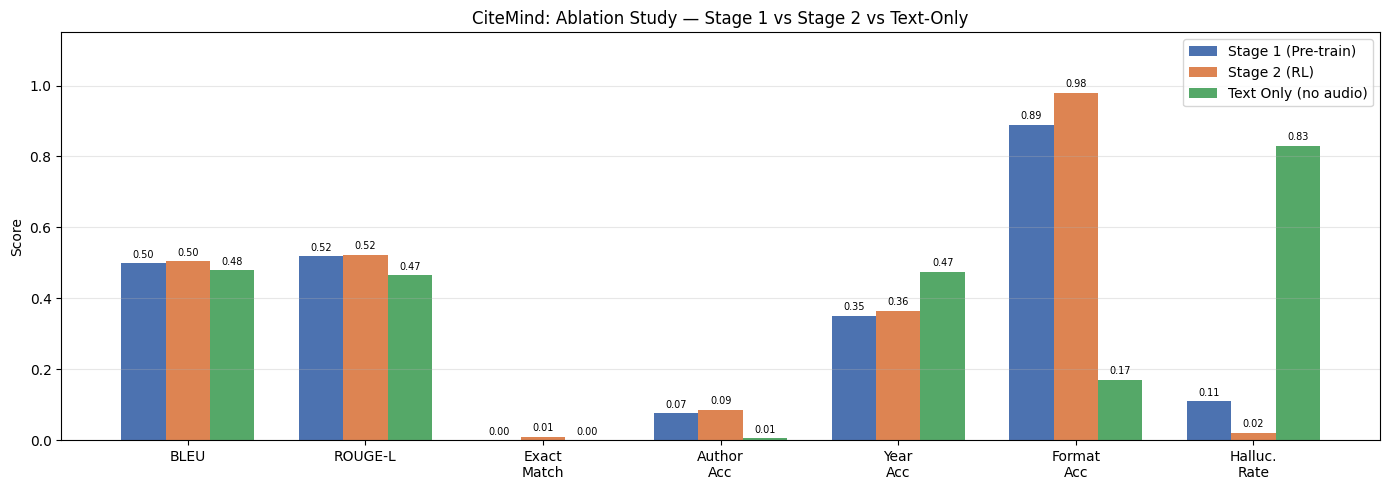

In [7]:
# ── Step 7: Ablation bar chart (3-way comparison) ────────────────────────
import matplotlib.pyplot as plt
import numpy as np

metric_names   = ['bleu', 'rouge_l', 'exact_match', 'author_accuracy', 'year_accuracy', 'format_accuracy', 'hallucination_rate']
display_names  = ['BLEU', 'ROUGE-L', 'Exact\nMatch', 'Author\nAcc', 'Year\nAcc', 'Format\nAcc', 'Halluc.\nRate']
colors         = ['#4C72B0', '#DD8452', '#55A868']
model_names    = ['Stage 1 (Pre-train)', 'Stage 2 (RL)', 'Text Only (no audio)']

x     = np.arange(len(metric_names))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 5))
for i, (mname, color) in enumerate(zip(model_names, colors)):
    vals = [results[mname]['averages'].get(m, 0) for m in metric_names]
    bars = ax.bar(x + (i - 1) * width, vals, width, label=mname, color=color)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2., h + 0.01,
                f'{h:.2f}', ha='center', va='bottom', fontsize=7)

ax.set_ylabel('Score')
ax.set_title('CiteMind: Ablation Study — Stage 1 vs Stage 2 vs Text-Only')
ax.set_xticks(x)
ax.set_xticklabels(display_names)
ax.legend(loc='upper right')
ax.set_ylim(0, 1.15)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
# ── Step 8: Side-by-side prediction samples ──────────────────────────────
import pandas as pd

n_show = 20
s1_preds = results['Stage 1 (Pre-train)']['predictions'][:n_show]
s2_preds = results['Stage 2 (RL)']['predictions'][:n_show]

rows = []
for i, (p1, p2) in enumerate(zip(s1_preds, s2_preds)):
    rows.append({
        '#': i + 1,
        'Reference': p1['reference'],
        'Stage 1': p1['generated'],
        'Stage 2 (RL)': p2['generated'],
    })

df = pd.DataFrame(rows)
print(df.to_string(index=False))

 #              Reference               Stage 1        Stage 2 (RL)
 1     Zarzà et al., 2023     Khou et al., 2023    Yiu et al., 2022
 2 Cvitkovic et al., 2018    Zhang et al., 2021   Xhou et al., 2023
 3   Agarwal et al., 2025     Wing et al., 2023  Huang et al., 2023
 4      Yang et al., 2024       Du et al., 2022   Yang et al., 2024
 5     Mosel et al., 2021     Tang et al., 2023   Lhen et al., 2022
 6     Zhang et al., 2017     Ling et al., 2022   Zhen et al., 2022
 7    Nassar et al., 2022       He et al., 2024    Ziu et al., 2023
 8    Mohbat et al., 2024     Lhen et al., 2023    Zuo et al., 2024
 9    Dodge et al. (2019)     Nhang et al. (21)     Li et al., 2021
10       Lin et al., 2022      Zing et al. (20)    Xao et al., 2023
11        Qi et al., 2023  Fasanna et al., 2020     Fu et al., 2023
12     Asiri et al., 2023   Zutham et al., 2024 Alrouv et al., 2023
13     Jiang et al., 2024      Zai et al., 2019    Wiu et al., 2022
14    Hadley et al., 2020   Pishna et al., 2019 

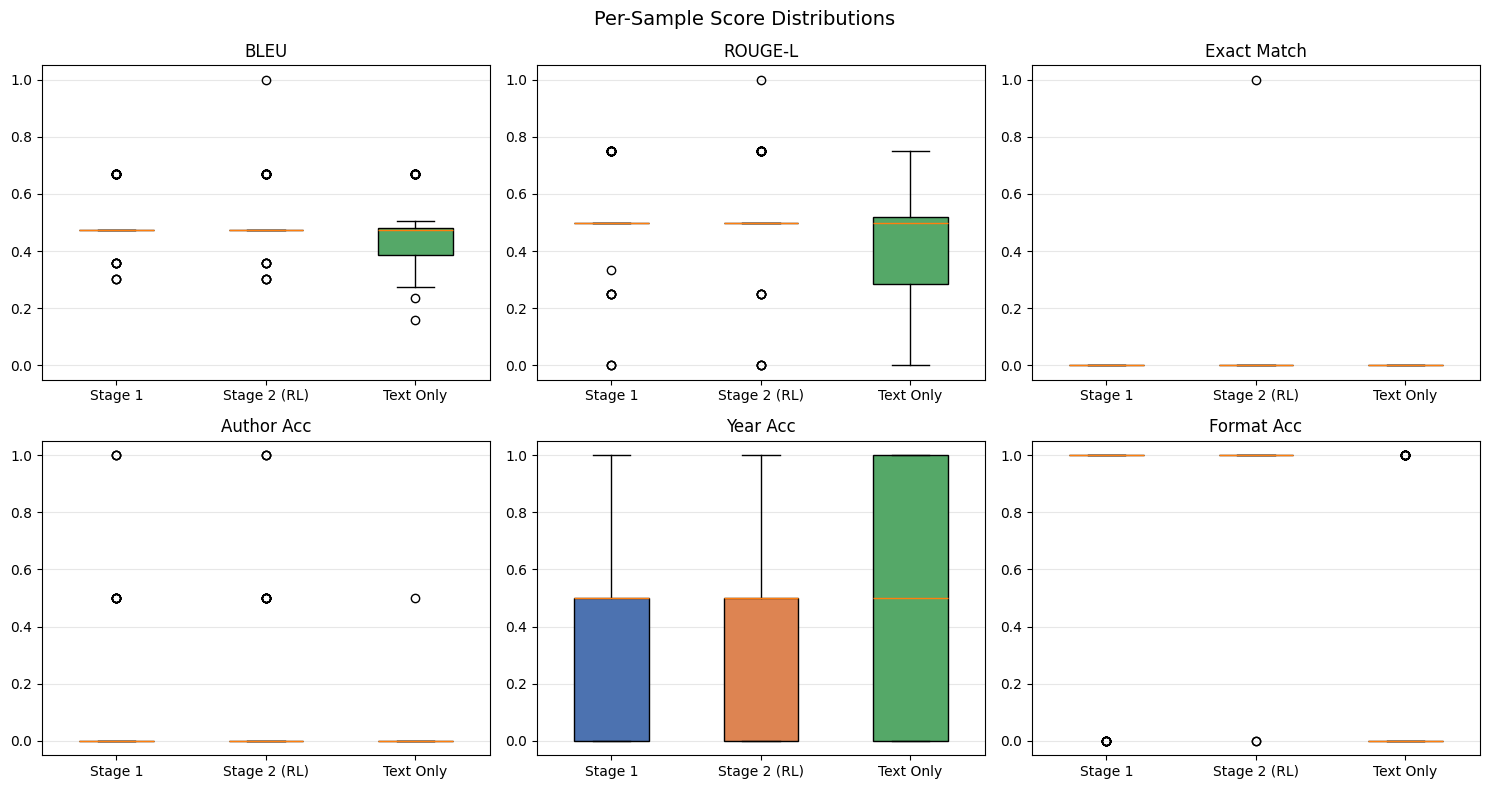

In [11]:
# ── Step 9: Per-metric distribution (box plot) ──────────────────────────
import matplotlib.pyplot as plt

# Only per-sample metrics (hallucination_rate, mrr_at_5, recall_at_5 are corpus-level)
per_sample_metrics  = ['bleu', 'rouge_l', 'exact_match', 'author_accuracy', 'year_accuracy', 'format_accuracy']
per_sample_displays = ['BLEU', 'ROUGE-L', 'Exact Match', 'Author Acc', 'Year Acc', 'Format Acc']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, (metric, display) in enumerate(zip(per_sample_metrics, per_sample_displays)):
    s1_scores  = [s[metric] for s in results['Stage 1 (Pre-train)']['per_sample']]
    s2_scores  = [s[metric] for s in results['Stage 2 (RL)']['per_sample']]
    txt_scores = [s[metric] for s in results['Text Only (no audio)']['per_sample']]

    bp = axes[idx].boxplot(
        [s1_scores, s2_scores, txt_scores],
        tick_labels=['Stage 1', 'Stage 2 (RL)', 'Text Only'],
        patch_artist=True,
        widths=0.5,
    )
    bp['boxes'][0].set_facecolor('#4C72B0')
    bp['boxes'][1].set_facecolor('#DD8452')
    bp['boxes'][2].set_facecolor('#55A868')

    axes[idx].set_title(display)
    axes[idx].set_ylim(-0.05, 1.05)
    axes[idx].grid(axis='y', alpha=0.3)

plt.suptitle('Per-Sample Score Distributions', fontsize=14)
plt.tight_layout()
plt.show()

In [12]:
# ── Step 9b: Inference Pipeline Demo ─────────────────────────────────────
import json
import src.main.inference.pipeline as _pipeline_module
from src.main.inference.pipeline import CitationPipeline

# Load the best RL checkpoint into the pipeline
pipeline = CitationPipeline(checkpoint_path=RL_CKPT, device=str(device))

# Run on first 5 test samples
with open(TEST_MANIFEST, 'r') as f:
    test_entries = json.load(f)

print("=" * 65)
print("INFERENCE PIPELINE DEMO  (Top-5 candidates per sample)")
print("=" * 65)

for i, entry in enumerate(test_entries[:5]):
    print(f"\n--- Sample {i+1} ---")
    print(f"Source   : {entry['source_title'][:70]}")
    print(f"Expected : {entry['citation_string']}")

    candidates = pipeline.predict(
        audio_path=entry['audio_path'],
        source_title=entry['source_title'],
        source_abstract=entry['source_abstract'],
        num_candidates=5,
        temperature=0.8,
    )

    for rank, c in enumerate(candidates, start=1):
        marker = " ✓" if c['citation'].lower().strip() == entry['citation_string'].lower().strip() else ""
        print(f"  #{rank} ({c['confidence']:.0%})  {c['citation']}{marker}")

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

[CitationPipeline] Loaded (step=450, best_reward=0.1594) on cuda
INFERENCE PIPELINE DEMO  (Top-5 candidates per sample)

--- Sample 1 ---
Source   : Context-aware LLM-based Safe Control Against Latent Risks
Expected : Zarzà et al., 2023
  #1 (20%)  Zui et al., 2024
  #2 (20%)  Xai et al., 2023
  #3 (20%)  Zama et al., 2024
  #4 (20%)  Yees et al., 2023
  #5 (20%)  Zhang et al., 2024

--- Sample 2 ---
Source   : Mucha: Multi-channel based Code Change Representation Learning for Com
Expected : Cvitkovic et al., 2018
  #1 (20%)  Lang et al., 2022
  #2 (20%)  Yiu et al., 2022
  #3 (20%)  Yang et al., 2022
  #4 (20%)  Yhen et al., 2022
  #5 (20%)  Win et al., 2021

--- Sample 3 ---
Source   : Q-Bridge: Code Translation for Quantum Machine Learning via LLMs
Expected : Agarwal et al., 2025
  #1 (20%)  Lang et al., 2022
  #2 (20%)  Ziu et al., 2024
  #3 (20%)  Guang et al., 2022
  #4 (20%)  Yang et al., 2022
  #5 (20%)  Lu et al., 2023

--- Sample 4 ---
Source   : Investigating Compositional R

In [13]:
# ── Step 10: Full Ablation Summary ───────────────────────────────────────
print('=' * 75)
print('CITÉMIND ABLATION SUMMARY')
print('=' * 75)

s1_avg  = results['Stage 1 (Pre-train)']['averages']
s2_avg  = results['Stage 2 (RL)']['averages']
txt_avg = results['Text Only (no audio)']['averages']

all_metrics = [
    ('BLEU',               'bleu'),
    ('ROUGE-L',            'rouge_l'),
    ('Exact Match',        'exact_match'),
    ('Author Accuracy',    'author_accuracy'),
    ('Year Accuracy',      'year_accuracy'),
    ('Format Accuracy',    'format_accuracy'),
    ('Hallucination Rate', 'hallucination_rate'),
    ('MRR@5',              'mrr_at_5'),
    ('Recall@5',           'recall_at_5'),
]

print(f'\n{"Metric":<22}  {"Text Only":>10}  {"Stage 1":>10}  {"Stage 2":>10}  {"RL Δ":>8}  {"Audio Δ":>8}')
print('-' * 75)
for display, key in all_metrics:
    t  = txt_avg.get(key, float('nan'))
    s1 = s1_avg.get(key, float('nan'))
    s2 = s2_avg.get(key, float('nan'))
    rl_delta    = s2 - s1          # RL contribution
    audio_delta = s1 - t           # audio contribution (Stage1 vs text-only)
    print(f'{display:<22}  {t:>10.4f}  {s1:>10.4f}  {s2:>10.4f}  {rl_delta:>+8.4f}  {audio_delta:>+8.4f}')

print(f'\nKey findings:')
print(f'  Audio contribution : Stage 1 vs Text-Only (positive = audio helps)')
print(f'  RL  contribution   : Stage 2 vs Stage 1   (positive = RL helps)')
print(f'  Format accuracy    : {s2_avg["format_accuracy"]:.1%} (Stage 2) vs {s1_avg["format_accuracy"]:.1%} (Stage 1) — RL enforces format')
print(f'  Hallucination rate : {s2_avg["hallucination_rate"]:.1%} (Stage 2) vs {s1_avg["hallucination_rate"]:.1%} (Stage 1)')
print(f'  Recall@5           : {s2_avg.get("recall_at_5", 0):.1%} (Stage 2) vs {s1_avg.get("recall_at_5", 0):.1%} (Stage 1)')
print(f'\nResults saved to: {EVAL_OUTPUT}')

CITÉMIND ABLATION SUMMARY

Metric                   Text Only     Stage 1     Stage 2      RL Δ   Audio Δ
---------------------------------------------------------------------------
BLEU                        0.4793      0.4982      0.5048   +0.0067   +0.0188
ROUGE-L                     0.4652      0.5183      0.5225   +0.0042   +0.0532
Exact Match                 0.0000      0.0000      0.0100   +0.0100   +0.0000
Author Accuracy             0.0050      0.0750      0.0850   +0.0100   +0.0700
Year Accuracy               0.4750      0.3500      0.3650   +0.0150   -0.1250
Format Accuracy             0.1700      0.8900      0.9800   +0.0900   +0.7200
Hallucination Rate          0.8300      0.1100      0.0200   -0.0900   -0.7200
MRR@5                       0.0000      0.0033      0.0020   -0.0013   +0.0033
Recall@5                    0.0000      0.0100      0.0100   +0.0000   +0.0100

Key findings:
  Audio contribution : Stage 1 vs Text-Only (positive = audio helps)
  RL  contribution   : 